In [1]:
import os
from dotenv import load_dotenv,find_dotenv
load_dotenv(find_dotenv())
from langchain.chat_models import init_chat_model

llm = init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001D87C5B6660>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001D87C5B70E0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [2]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool 
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition

from langgraph.types import Command,interrupt 

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistant(query:str)->str:
    """ Request assistance from a human expert. Use this tool when you need human guidance. """
    human_response = interrupt({"query":query})
    return human_response["data"]

tool=TavilySearch(max_result=2)

tools = [tool,human_assistant]

llm_with_tools =llm.bind_tools(tools)

def chatbot(state:State):
    message = llm_with_tools.invoke(state["messages"])

    return {"messages":[message]}

graph_builder.add_node("ChatBot",chatbot)
tool_node = ToolNode(tools=tools)

graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges(
    "ChatBot",
    tools_condition,
)
graph_builder.add_edge(START,"ChatBot")
graph_builder.add_edge("tools","ChatBot")




 

In [3]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

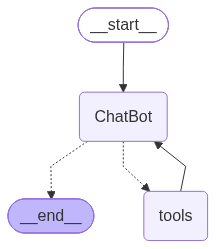

In [4]:
from IPython.display import display,Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
user_input ="i need some expert guidance and assistance for building ai agent . could you request assistant for me?"
config ={"configurable":{"thread_id":"1"}}

events = graph.stream({"messages":user_input},config=config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

i need some expert guidance and assistance for building ai agent . could you request assistant for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistant (xzvz2ecs7)
 Call ID: xzvz2ecs7
  Args:
    query: I need expert guidance and assistance for building an AI agent. Could you provide me with some advice and direction on how to get started and what resources I might need?
================================== Ai Message ==================================
Tool Calls:
  human_assistant (xzvz2ecs7)
 Call ID: xzvz2ecs7
  Args:
    query: I need expert guidance and assistance for building an AI agent. Could you provide me with some advice and direction on how to get started and what resources I might need?


In [8]:
human_response =("Use LangGraph. It is the best framework. I have no further advice, please respond to the user now."
    "its much more relaibale and extensible than simple autonomous agents"
    )

human_command = Command(resume={"data":human_response})

events = graph.stream(human_command,config,stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()


================================== Ai Message ==================================
Tool Calls:
  human_assistant (1v7mkw35k)
 Call ID: 1v7mkw35k
  Args:
    query: What are the key components and features of LangGraph that make it a reliable and extensible option for building an AI agent?
================================= Tool Message =================================
Name: human_assistant

Use LangGraph. It is the best framework. I have no further advice, please respond to the user now.its much more relaibale and extensible than simple autonomous agents
================================== Ai Message ==================================

Based on the expert's guidance, it seems that LangGraph is a suitable framework for building an AI agent. The expert has stated that it is more reliable and extensible than simple autonomous agents. If you have any further questions or need more information about LangGraph, feel free to ask. Otherwise, you can consider exploring LangGraph as a potential sol